## Ridge Regretion Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
X=data.data
y=data.target

### Simpply Applying Linear Regression First

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [6]:
from sklearn.linear_model import LinearRegression
L=LinearRegression()

In [7]:
L.fit(X_train,y_train)

LinearRegression()

In [8]:
print(L.coef_) # m slope
print(L.intercept_) # b intercept

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [9]:
y_pred=L.predict(X_test)

In [10]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.5188113124539246
RMSE 48.727137609532534


### Applying Ridge Regression 

In [11]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=0.01)

we change the alpha value its tuning parameter, we cal also use gridsearchcv 

In [12]:
R.fit(X_train,y_train)

Ridge(alpha=0.01)

In [13]:
print(R.coef_)
print(R.intercept_)

[  26.26181052 -240.39934227  496.57507972  326.6599829  -420.98179086
  137.89180358  -53.05692237  194.22314385  581.45028172   94.31369289]
152.08329034119228


In [14]:
y_pred1=R.predict(X_test)

In [15]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score 0.5230847087541541
RMSE 48.5102842644092


RSquare is slighly different from linear regression 

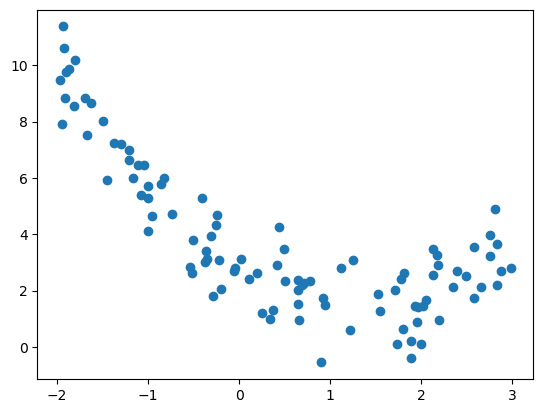

In [16]:
# Generating synthetic nonlinear data for testing Ridge Regression

m = 100  # Number of samples (data points)

# INPUT FEATURE: x1
# np.random.rand(m, 1) generates m rows and 1 column of samples from a uniform distribution over [0, 1)
# Multiplying by 5 scales the range to [0, 5)
# Subtracting 2 shifts the range to [-2, 3)
# So, x1 ∈ [-2, 3), simulating input values within this interval
x1 = 5 * np.random.rand(m, 1) - 2

# TARGET OUTPUT: x2
# The true underlying relationship is defined by a **quadratic function** of x1:
#      x2 = 0.7 * x1^2 - 2 * x1 + 3 + ε
#      where ε ∼ N(0, 1) is Gaussian noise added via np.random.randn
#
# Why quadratic?
# - This structure creates a **nonlinear relationship** between x1 and x2.
# - It's useful for testing how well Ridge Regression (or other models) can fit nonlinear patterns
#   especially when using polynomial feature transformations.
#
# Noise term:
# - np.random.randn(m, 1) generates m×1 samples from the standard normal distribution.
# - This simulates real-world noise/variability in the target variable.

x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)


plt.scatter(x1, x2)
plt.show()

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np

# Function to create predictions using Ridge Regression
def get_preds_ridge(x1, x2, alpha):
    # This pipeline does 2 things:
    # 1. Transforms x1 into polynomial features (up to degree 16)
    # 2. Fits a Ridge Regression model using regularization strength 'alpha'
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)  
    return model.predict(x1) 


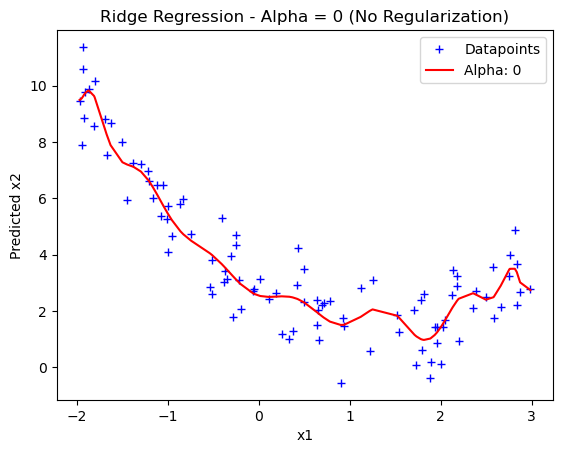

In [19]:
alpha = 0
preds = get_preds_ridge(x1, x2, alpha)

plt.plot(x1, x2, 'b+', label='Datapoints')
sorted_x = np.argsort(x1[:, 0])
plt.plot(x1[sorted_x], preds[sorted_x], 'r', label='Alpha: 0')
plt.legend()
plt.title("Ridge Regression - Alpha = 0 (No Regularization)")
plt.xlabel("x1")
plt.ylabel("Predicted x2")
plt.show()


-  The curve fits every little change in the data.

- It’s trying too hard to be accurate on the training data.

- This behavior is typical of overfitting.

- It has low bias (makes very accurate predictions on training) but high variance (bad on unseen data).

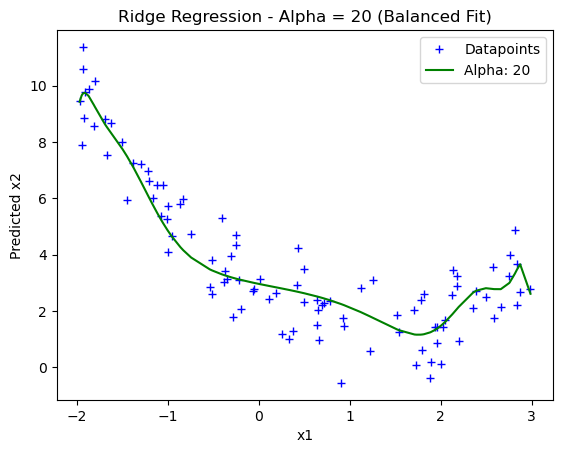

In [20]:
alpha = 20
preds = get_preds_ridge(x1, x2, alpha)

plt.plot(x1, x2, 'b+', label='Datapoints')
sorted_x = np.argsort(x1[:, 0])
plt.plot(x1[sorted_x], preds[sorted_x], 'g', label='Alpha: 20')
plt.legend()
plt.title("Ridge Regression - Alpha = 20 (Balanced Fit)")
plt.xlabel("x1")
plt.ylabel("Predicted x2")
plt.show()


- Smooth, but not overly simple.

- Captures the main curve and ignores noise.

- This is a balanced trade-off between model complexity and generalization.

- It's likely the best choice among the three in real-world testing.

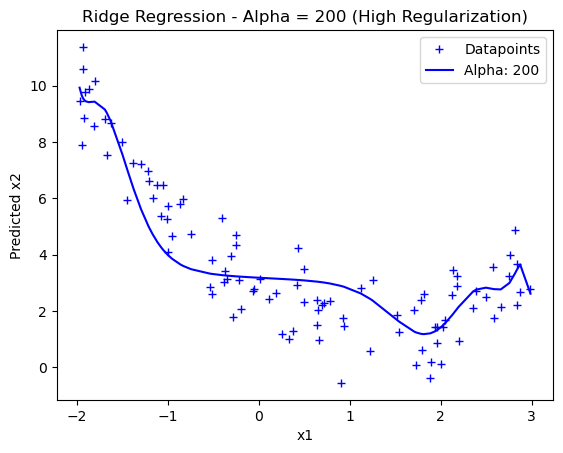

In [21]:
alpha = 200
preds = get_preds_ridge(x1, x2, alpha)

plt.plot(x1, x2, 'b+', label='Datapoints')
sorted_x = np.argsort(x1[:, 0])
plt.plot(x1[sorted_x], preds[sorted_x], 'b', label='Alpha: 200')
plt.legend()
plt.title("Ridge Regression - Alpha = 200 (High Regularization)")
plt.xlabel("x1")
plt.ylabel("Predicted x2")
plt.show()


- The model looks too flat, especially in the middle.

- It doesn't follow the curve well.

- This is classic underfitting — model is too simple, and doesn't learn enough.

- It has high bias and low variance, meaning it's consistently wrong in a simple way.

## Merging all the graphs : 

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np

# Function to create predictions using Ridge Regression
def get_preds_ridge(x1, x2, alpha):
    # This pipeline does 2 things:
    # 1. Transforms x1 into polynomial features (up to degree 16)
    # 2. Fits a Ridge Regression model using regularization strength 'alpha'
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)  
    return model.predict(x1) 


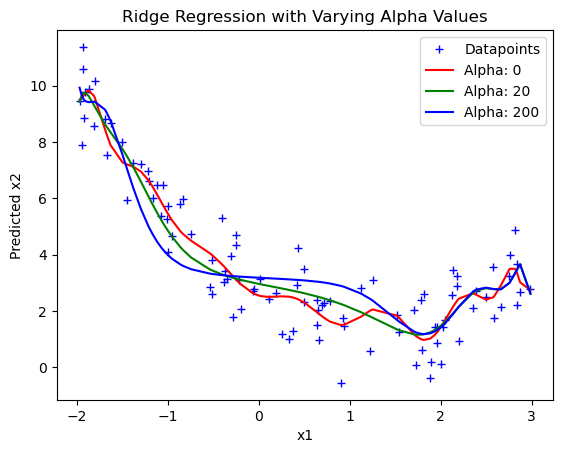

In [23]:
alphas = [0, 20, 200]  # Different alpha values
colors = ['r', 'g', 'b']  # Colors for plotting each model

plt.plot(x1, x2, 'b+', label='Datapoints') # datapoints

# Loop through each alpha and plot the corresponding model
for alpha, color in zip(alphas, colors):
    preds = get_preds_ridge(x1, x2, alpha)  # Get predicted y values
    sorted_x = np.argsort(x1[:, 0])  # Sort x1 for a smooth curve
    plt.plot(x1[sorted_x], preds[sorted_x], color, label=f'Alpha: {alpha}')

plt.legend()
plt.title("Ridge Regression with Varying Alpha Values")
plt.xlabel("x1")
plt.ylabel("Predicted x2")
plt.show()


In [24]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [25]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

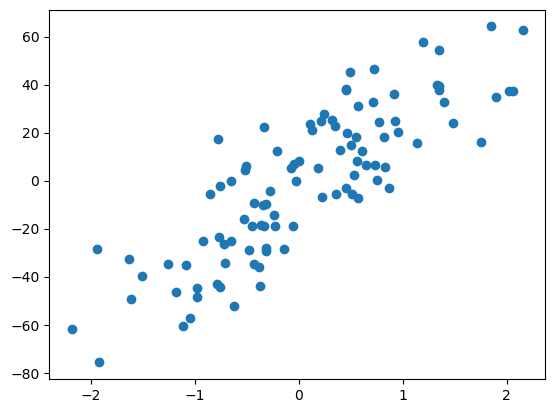

In [26]:
plt.scatter(X,y)


In [27]:
from sklearn.linear_model import LinearRegression


In [28]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [29]:
from sklearn.linear_model import Ridge


In [30]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235726


In [31]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


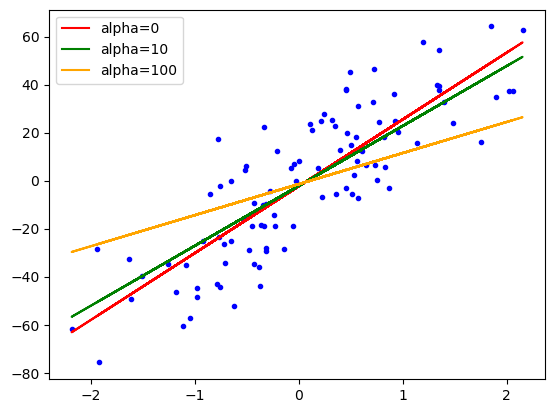

In [32]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [33]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()
    
    num = 0 # numerator
    den = 0 # denominator
    
    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)
        
    m = num/(den + alpha)
    b = y_mean - m*x_mean
        
    return m,b

In [34]:
class MyRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0 # numerator
        den = 0 # denominator
        
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())
        
        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)
    
    def predict(X_test):
        pass

In [35]:
reg = MyRidge(alpha = 10)

In [36]:
reg.fit(X,y)

[24.9546267] [-2.126913]


In [37]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235726


In [38]:
reg = MyRidge(alpha = 100)

In [39]:
reg.fit(X,y)

[12.93442104] [-1.42484415]


In [40]:
rr = Ridge(alpha=100)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[12.93442104]
-1.4248441496033308


## Ridge Regression for n-D Data

In [41]:
X,y = load_diabetes(return_X_y=True)


In [42]:
from sklearn.model_selection import train_test_split


In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)


In [44]:
from sklearn.linear_model import Ridge


In [45]:
reg = Ridge(alpha=0.1,solver='cholesky')
# solver = cholesky, 
# there are many for eg, sag,saga
# in backend they may use OLS or gradient decent 

OLS-based (Closed-form) methods:

- 'cholesky'
 
- 'svd'

Gradient Descent–based (Iterative) methods:

- 'sag', 'saga', 'lsqr'


In [46]:
reg.fit(X_train,y_train)


Ridge(alpha=0.1, solver='cholesky')

In [47]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.46931288533098037

In [48]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [49]:
class MyRidge:
    
    def __init__(self, alpha=0.1):
        """
        Constructor to initialize the Ridge Regression model.

        Parameters:
        - alpha: float
            Regularization strength (λ). Higher value means more regularization.
        """
        self.alpha = alpha              # Store regularization strength
        self.coef_ = None               # To store learned feature weights
        self.intercept_ = None          # To store the learned bias term

    
    def fit(self, X_train, y_train):
        """
        Train the Ridge Regression model using the closed-form formula:
        
        θ = (XᵀX + αI)⁻¹ Xᵀy

        Parameters:
        - X_train: ndarray of shape (n_samples, n_features)
            Input training data
        - y_train: ndarray of shape (n_samples,)
            Target values
        """
        # Add a column of 1s at the beginning of X_train to account for the bias (intercept)
        # After this, the first column will be 1 for all samples
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Create an identity matrix of shape (n_features + 1, n_features + 1)
        # This is used for regularization. We'll exclude the intercept term from regularization
        I = np.identity(X_train.shape[1])

        # Don't regularize the intercept (bias term)
        I[0][0] = 0

        # Apply the closed-form solution of Ridge Regression
        # (XᵀX + αI)^(-1) Xᵀ y
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.alpha * I).dot(X_train.T).dot(y_train)

        # First value is the intercept (bias term)
        self.intercept_ = result[0]

        # Remaining values are the feature coefficients
        self.coef_ = result[1:]

    
    def predict(self, X_test):
        """
        Predict the output for given input samples using the learned model.
        
        Parameters:
        - X_test: ndarray of shape (n_samples, n_features)
            Test data (should NOT include bias column)
        
        Returns:
        - predictions: ndarray of shape (n_samples,)
        """
        # Perform dot product of input with weights, then add bias
        return np.dot(X_test, self.coef_) + self.intercept_


In [50]:
reg = MyRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.46931288533098037
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


## Ridge Regression in Gradient Descent

In [51]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [52]:
X,y = load_diabetes(return_X_y=True)


In [53]:
from sklearn.model_selection import train_test_split


In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)


In [55]:
from sklearn.linear_model import SGDRegressor


In [56]:
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)


In [57]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.45941130410600983
[  51.75042369 -156.17880778  365.52698545  272.85094827   -6.6037795
  -60.26859896 -165.22786069  134.76235201  331.47235053   97.75236221]
[155.1925073]


In [58]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [59]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.46250101621910966
[  34.52193893 -290.84082896  482.4018325   368.0678841  -852.44871106
  501.59162397  180.11113982  270.76336652  759.73536846   37.49137396]
151.10198522135005


In [60]:
class MyRidgeGD:
    
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [61]:
reg = MyRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)


In [62]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4738018280260914
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472


## 5 Key Points Ridge Regression

### 1. How are coefficients affected?

In [63]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [64]:
data = load_diabetes()


In [65]:

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

In [66]:
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [67]:
df.shape


(442, 11)

In [68]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [69]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

In [70]:

coefs = []
r2_scores = []

for i in [0,10,100,1000]:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))
    

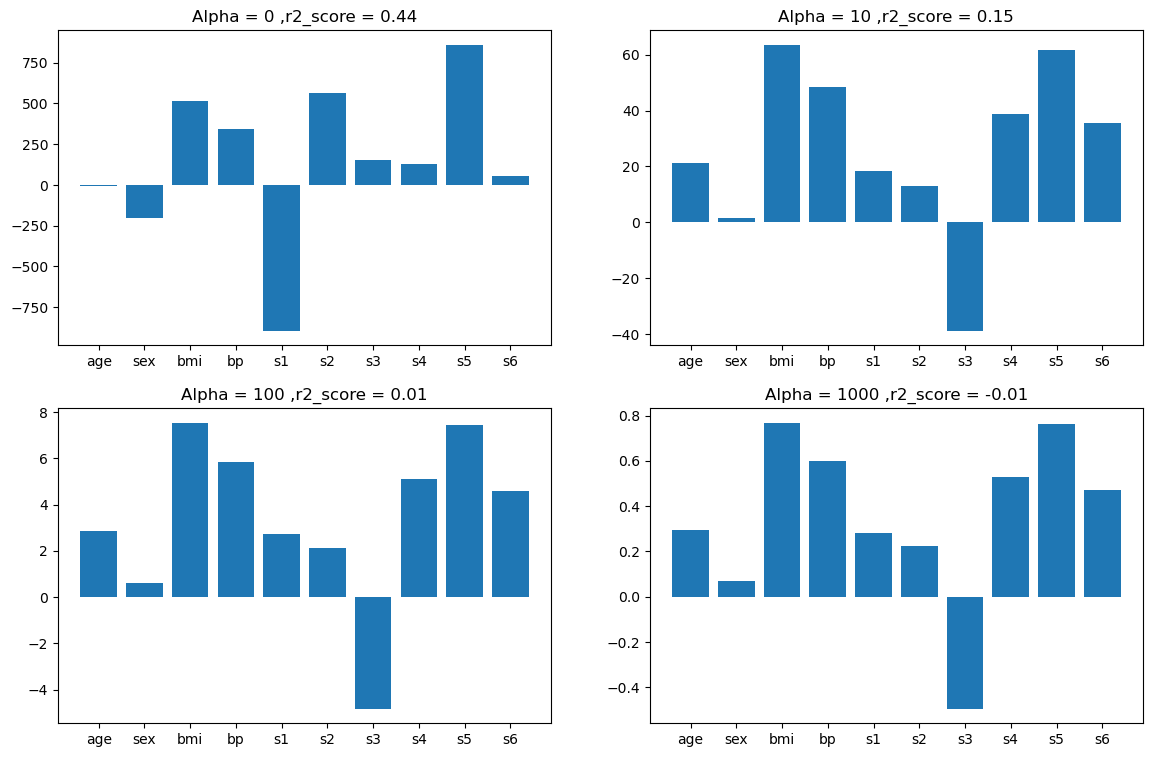

In [71]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('Alpha = 0 ,r2_score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('Alpha = 10 ,r2_score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('Alpha = 100 ,r2_score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('Alpha = 1000 ,r2_score = {}'.format(round(r2_scores[3],2)))

plt.show()

### 2. Higher Coefficients are affected more

In [72]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [73]:
input_array = np.array(coefs)


In [74]:
coef_df = pd.DataFrame(input_array,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.116119,-205.329219,516.889664,340.549436,-883.423872,551.559582,148.587063,125.353015,856.485935,52.468916
0.0010,-8.761487,-204.313404,518.380608,339.967926,-787.700510,475.282181,106.795253,114.629265,819.745723,52.873349
0.0100,-6.399507,-198.662945,522.056516,336.340595,-383.717571,152.670882,-66.053243,75.608209,659.875219,55.829221
0.1000,6.643733,-172.237474,485.529585,314.675846,-72.940209,-80.588688,-174.463527,83.614710,484.365316,73.585091
1.0000,42.242528,-57.304483,282.172125,198.059395,14.363734,-22.551079,-136.929684,102.023069,260.104294,98.552692
10.0000,21.174024,1.659837,63.659826,48.492858,18.421510,12.875466,-38.915435,38.842475,61.612302,35.505383
100.0000,2.858980,0.629453,7.540605,5.849949,2.710879,2.142135,-4.834047,5.108223,7.448451,4.576129
1000.0000,0.295726,0.069290,0.769004,0.597824,0.282900,0.225936,-0.495607,0.527031,0.761496,0.471029


In [75]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train,y_train)
    
    coefs.append(reg.coef_.tolist())

In [76]:
input_array = np.array(coefs).T


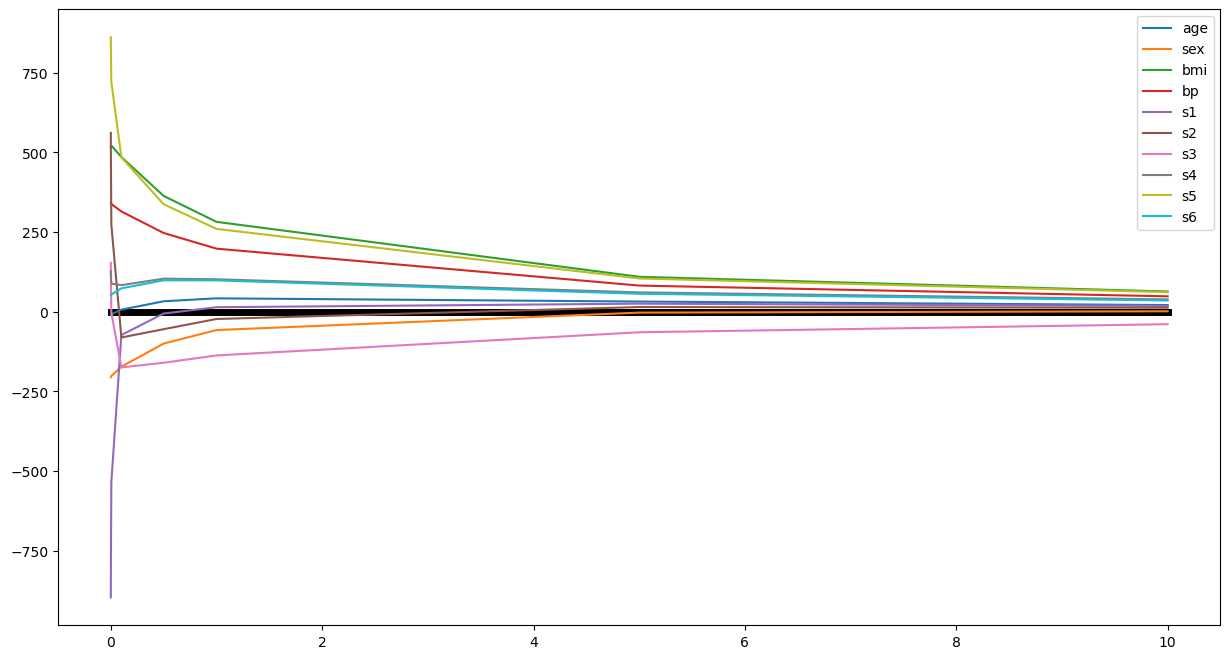

In [77]:

plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()

### 3. Impact on Bias and variance

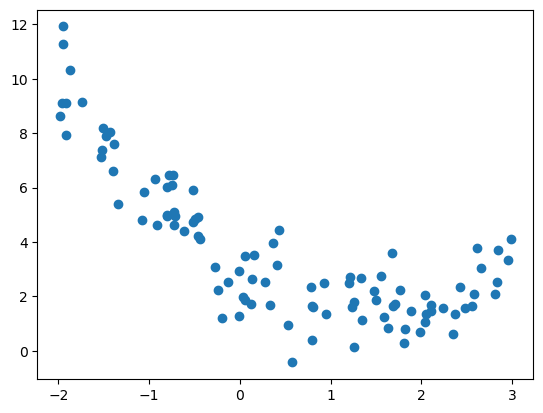

In [78]:
m = 100
X = 5 * np.random.rand(m, 1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m, 1)

plt.scatter(X, y)
plt.show()

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X.reshape(100,1),y.reshape(100),test_size=0.2,random_state=2)

In [80]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [81]:
from mlxtend.evaluate import bias_variance_decomp # this modules calculate bias and variance for each epochs

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

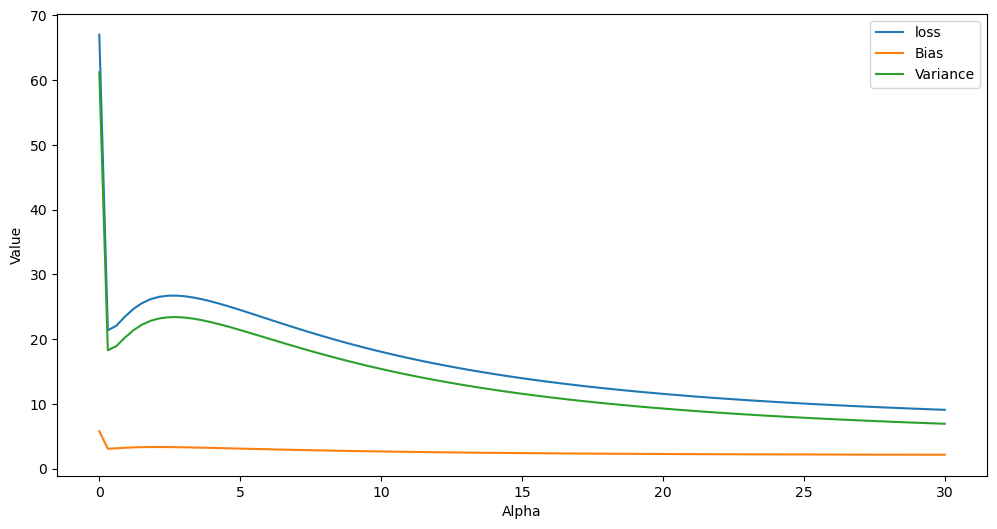

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(alphas, loss, label='loss')
plt.plot(alphas, bias, label='Bias')
plt.plot(alphas, variance, label='Variance')
plt.xlabel('Alpha')
plt.ylabel('Value')
plt.legend()
plt.show()

### 4. Effect of Regularization on Loss Function

[27.82809103]
-2.29474455867698


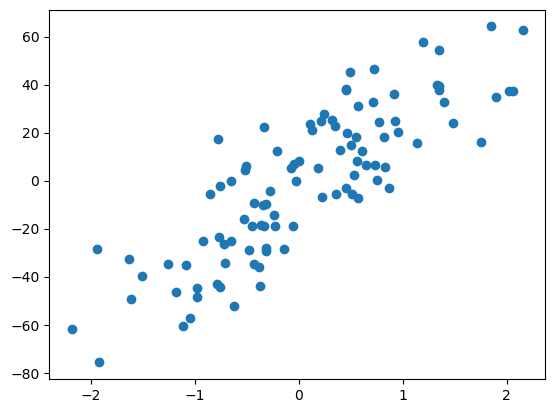

In [90]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [91]:

def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*m*m

In [92]:
def predict(m):
    return m*X - 2.29

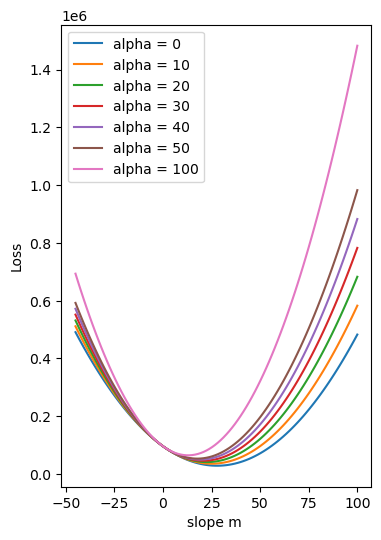

In [93]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(4,6))
for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha = {}'.format(j))
plt.legend()
plt.xlabel('slope m ')
plt.ylabel('Loss')
plt.show()

### for 2 coefficients
<img src='https://explained.ai/regularization/images/lagrange-animation.gif'>